In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
file_path = "../../DATASET/real_car_2.csv"
df = pd.read_csv(file_path)
df.head(5)

,Timestamp,STATUS,FUEL_STATUS,ENGINE_LOAD,COOLANT_TEMP,SHORT_FUEL_TRIM_1,LONG_FUEL_TRIM_1,INTAKE_PRESSURE,RPM,SPEED,...,DISTANCE_SINCE_DTC_CLEAR,BAROMETRIC_PRESSURE,PIDS_C,CONTROL_MODULE_VOLTAGE,ABSOLUTE_LOAD,RELATIVE_THROTTLE_POS,THROTTLE_POS_B,ACCELERATOR_POS_D,ACCELERATOR_POS_E,THROTTLE_ACTUATOR
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,01101010110100000000000000000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.726065e+09,<obd.OBDResponse.Status object at 0x7f2d8f2a1d10>,"('Closed loop, using oxygen sensor feedback to...",33.333333,87.0,2.34375,4.6875,42.0,847.0,0.0,...,52301.0,100.0,01101010110100000000000000000000,12.957,25.098039,7.058824,17.254902,14.901961,7.45098,9.411765
3,1.726065e+09,<obd.OBDResponse.Status object at 0x7f2d8f152f10>,"('Closed loop, using oxygen sensor feedback to...",33.333333,87.0,0.78125,4.6875,42.0,840.5,0.0,...,52301.0,100.0,01101010110100000000000000000000,13.099,25.490196,7.450980,17.254902,14.509804,7.45098,9.411765
4,1.726065e+09,<obd.OBDResponse.Status object at 0x7f2d8f154590>,"('Closed loop, using oxygen sensor feedback to...",33.333333,87.0,2.34375,4.6875,42.0,850.5,0.0,...,52301.0,100.0,01101010110100000000000000000000,12.934,25.098039,7.058824,17.254902,14.509804,7.45098,9.411765


In [3]:

df["Timestamp"] = pd.to_datetime(df["Timestamp"],unit='s')
df = df.set_index("Timestamp")

In [4]:
df.drop_duplicates()

,STATUS,FUEL_STATUS,ENGINE_LOAD,COOLANT_TEMP,SHORT_FUEL_TRIM_1,LONG_FUEL_TRIM_1,INTAKE_PRESSURE,RPM,SPEED,TIMING_ADVANCE,...,DISTANCE_SINCE_DTC_CLEAR,BAROMETRIC_PRESSURE,PIDS_C,CONTROL_MODULE_VOLTAGE,ABSOLUTE_LOAD,RELATIVE_THROTTLE_POS,THROTTLE_POS_B,ACCELERATOR_POS_D,ACCELERATOR_POS_E,THROTTLE_ACTUATOR
Timestamp,,,,,,,,,,,,,,,,,,,,,
NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,01101010110100000000000000000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-11 14:24:00.141294003,<obd.OBDResponse.Status object at 0x7f2d8f2a1d10>,"('Closed loop, using oxygen sensor feedback to...",33.333333,87.0,2.34375,4.68750,42.0,847.0,0.0,3.5,...,52301.0,100.0,01101010110100000000000000000000,12.957,25.098039,7.058824,17.254902,14.901961,7.450980,9.411765
2024-09-11 14:24:01.677148581,<obd.OBDResponse.Status object at 0x7f2d8f152f10>,"('Closed loop, using oxygen sensor feedback to...",33.333333,87.0,0.78125,4.68750,42.0,840.5,0.0,4.5,...,52301.0,100.0,01101010110100000000000000000000,13.099,25.490196,7.450980,17.254902,14.509804,7.450980,9.411765
2024-09-11 14:24:03.207092762,<obd.OBDResponse.Status object at 0x7f2d8f154590>,"('Closed loop, using oxygen sensor feedback to...",33.333333,87.0,2.34375,4.68750,42.0,850.5,0.0,3.0,...,52301.0,100.0,01101010110100000000000000000000,12.934,25.098039,7.058824,17.254902,14.509804,7.450980,9.411765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-11 16:16:19.299604893,<obd.OBDResponse.Status object at 0x7feded6b5490>,('Open loop due to engine load OR fuel cut due...,47.058824,90.0,0.00000,3.12500,51.0,1035.0,5.0,21.0,...,52382.0,100.0,01101010110100000000000000000000,12.062,16.862745,6.274510,16.470588,14.901961,7.450980,8.235294
2024-09-11 16:16:20.835587502,<obd.OBDResponse.Status object at 0x7feded6a4ed0>,"('Closed loop, using oxygen sensor feedback to...",31.764706,90.0,-0.78125,2.34375,53.0,1103.0,5.0,18.5,...,52382.0,100.0,01101010110100000000000000000000,12.038,38.039216,10.980392,20.784314,23.529412,11.764706,13.333333
2024-09-11 16:16:22.371637583,<obd.OBDResponse.Status object at 0x7fedee066490>,"('Closed loop, using oxygen sensor feedback to...",40.000000,90.0,0.00000,3.12500,44.0,1456.0,10.0,21.5,...,52382.0,100.0,01101010110100000000000000000000,12.086,28.235294,10.196078,20.000000,25.098039,12.941176,15.686275


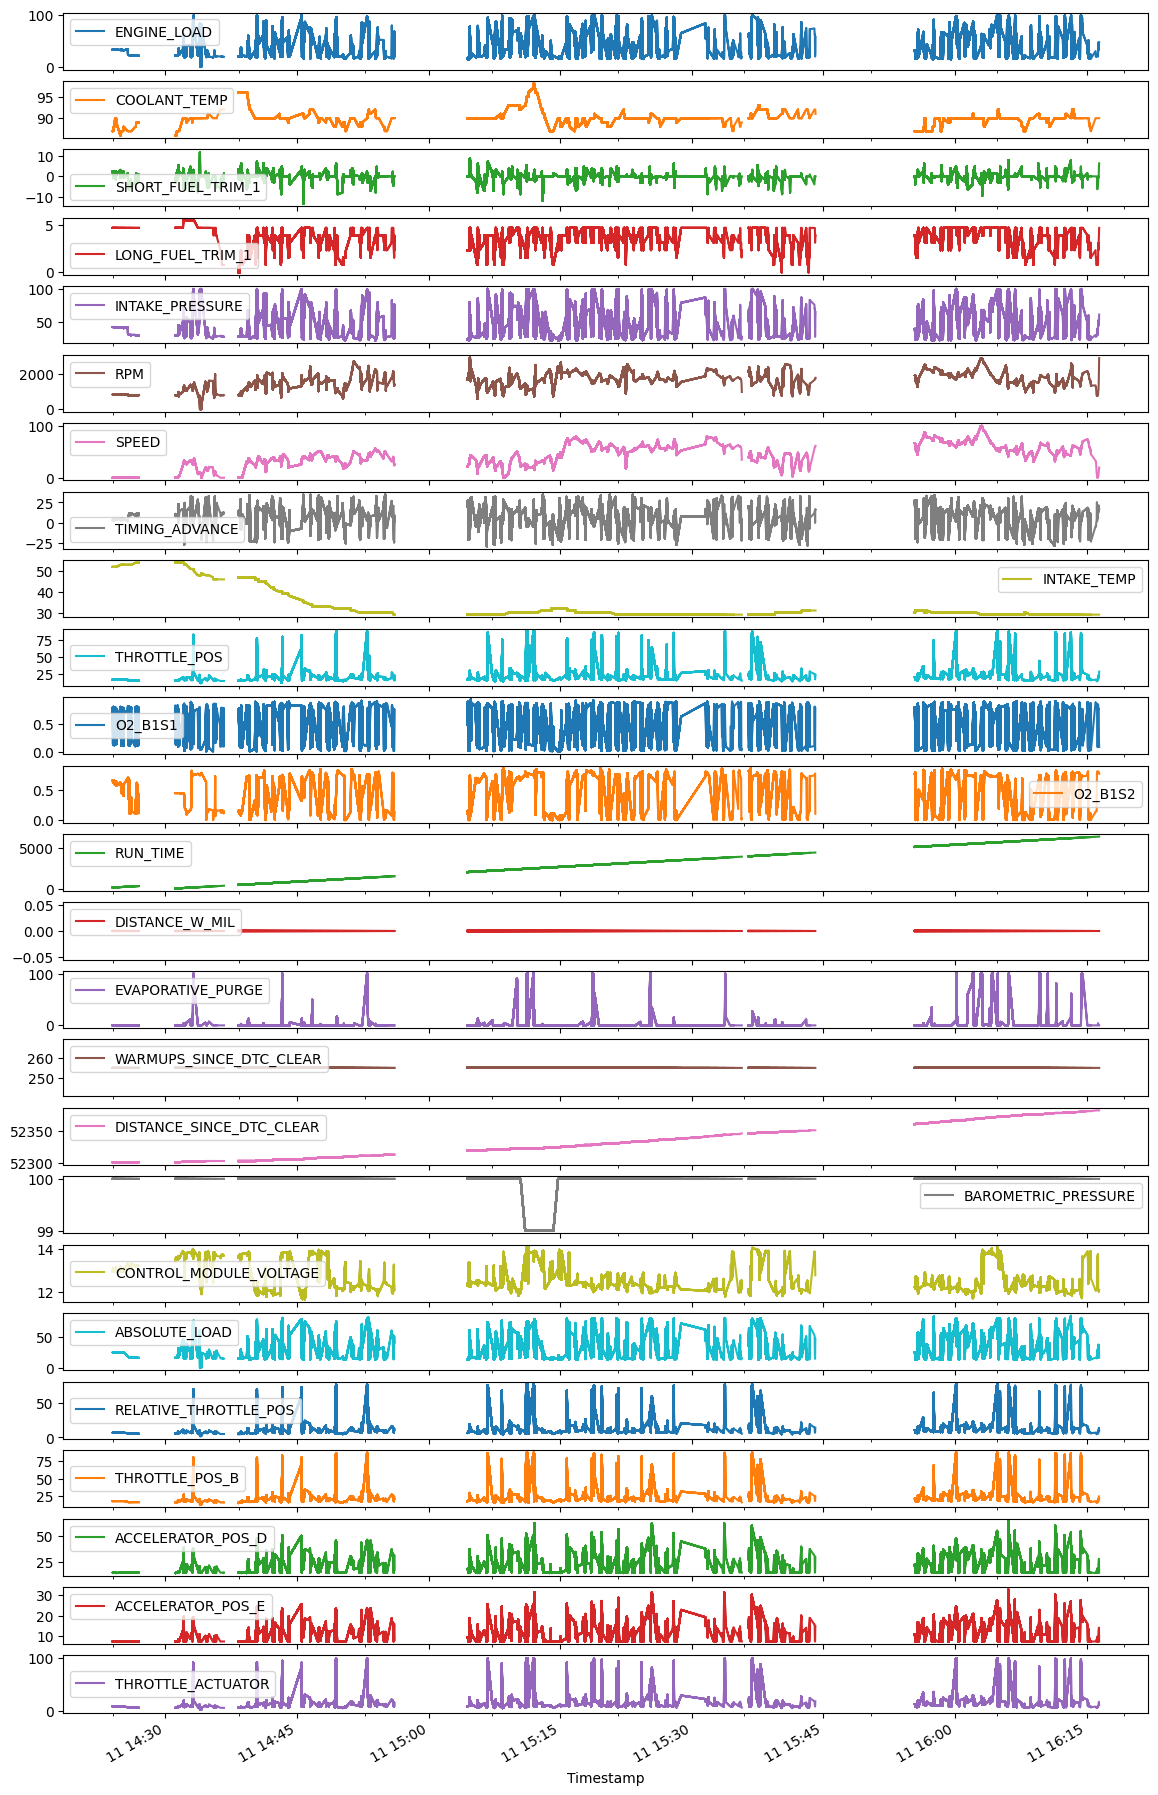

In [5]:
df.plot(subplots=True, figsize=(14,25))
plt.show()

In [6]:
print(df.count())
print(f"the number of rows in the data is: ", len(df))

STATUS                      18557
FUEL_STATUS                 18533
ENGINE_LOAD                 18557
COOLANT_TEMP                18557
SHORT_FUEL_TRIM_1           18557
LONG_FUEL_TRIM_1            18557
INTAKE_PRESSURE             18557
RPM                         18557
SPEED                       18557
TIMING_ADVANCE              18557
INTAKE_TEMP                 18557
THROTTLE_POS                18557
O2_SENSORS                  18557
O2_B1S1                     18554
O2_B1S2                     18554
OBD_COMPLIANCE              18554
RUN_TIME                    18554
PIDS_B                      18557
DISTANCE_W_MIL              18554
EVAPORATIVE_PURGE           18554
WARMUPS_SINCE_DTC_CLEAR     18554
DISTANCE_SINCE_DTC_CLEAR    18551
BAROMETRIC_PRESSURE         18551
PIDS_C                      18557
CONTROL_MODULE_VOLTAGE      18551
ABSOLUTE_LOAD               18551
RELATIVE_THROTTLE_POS       18551
THROTTLE_POS_B              18551
ACCELERATOR_POS_D           18551
ACCELERATOR_PO

In [7]:
df = df.iloc[10:]
df.head()

,STATUS,FUEL_STATUS,ENGINE_LOAD,COOLANT_TEMP,SHORT_FUEL_TRIM_1,LONG_FUEL_TRIM_1,INTAKE_PRESSURE,RPM,SPEED,TIMING_ADVANCE,...,DISTANCE_SINCE_DTC_CLEAR,BAROMETRIC_PRESSURE,PIDS_C,CONTROL_MODULE_VOLTAGE,ABSOLUTE_LOAD,RELATIVE_THROTTLE_POS,THROTTLE_POS_B,ACCELERATOR_POS_D,ACCELERATOR_POS_E,THROTTLE_ACTUATOR
Timestamp,,,,,,,,,,,,,,,,,,,,,
2024-09-11 14:24:12.411050081,<obd.OBDResponse.Status object at 0x7f2d8f157910>,"('Closed loop, using oxygen sensor feedback to...",33.333333,89.0,-0.78125,4.6875,42.0,851.5,0.0,3.5,...,52301.0,100.0,01101010110100000000000000000000,13.028,25.098039,7.058824,17.254902,14.901961,7.45098,9.411765
2024-09-11 14:24:13.953119516,<obd.OBDResponse.Status object at 0x7f2d8f151550>,"('Closed loop, using oxygen sensor feedback to...",33.725490,89.0,1.56250,4.6875,42.0,850.5,0.0,3.5,...,52301.0,100.0,01101010110100000000000000000000,13.099,25.490196,7.058824,17.254902,14.901961,7.45098,9.411765
2024-09-11 14:24:15.489165783,<obd.OBDResponse.Status object at 0x7f2d8f151450>,"('Closed loop, using oxygen sensor feedback to...",33.333333,90.0,-0.78125,4.6875,42.0,851.0,0.0,4.5,...,52301.0,100.0,01101010110100000000000000000000,13.004,25.098039,7.058824,17.254902,14.901961,7.45098,9.411765
2024-09-11 14:24:17.019103527,<obd.OBDResponse.Status object at 0x7f2d8f156890>,"('Closed loop, using oxygen sensor feedback to...",33.725490,90.0,1.56250,4.6875,42.0,851.0,0.0,3.5,...,52301.0,100.0,01101010110100000000000000000000,13.028,25.098039,7.450980,17.254902,14.901961,7.45098,9.411765
2024-09-11 14:24:18.548588514,<obd.OBDResponse.Status object at 0x7f2d8f157550>,"('Closed loop, using oxygen sensor feedback to...",33.333333,90.0,2.34375,4.6875,42.0,849.0,0.0,3.5,...,52301.0,100.0,01101010110100000000000000000000,12.934,25.098039,7.058824,17.254902,14.901961,7.45098,9.411765


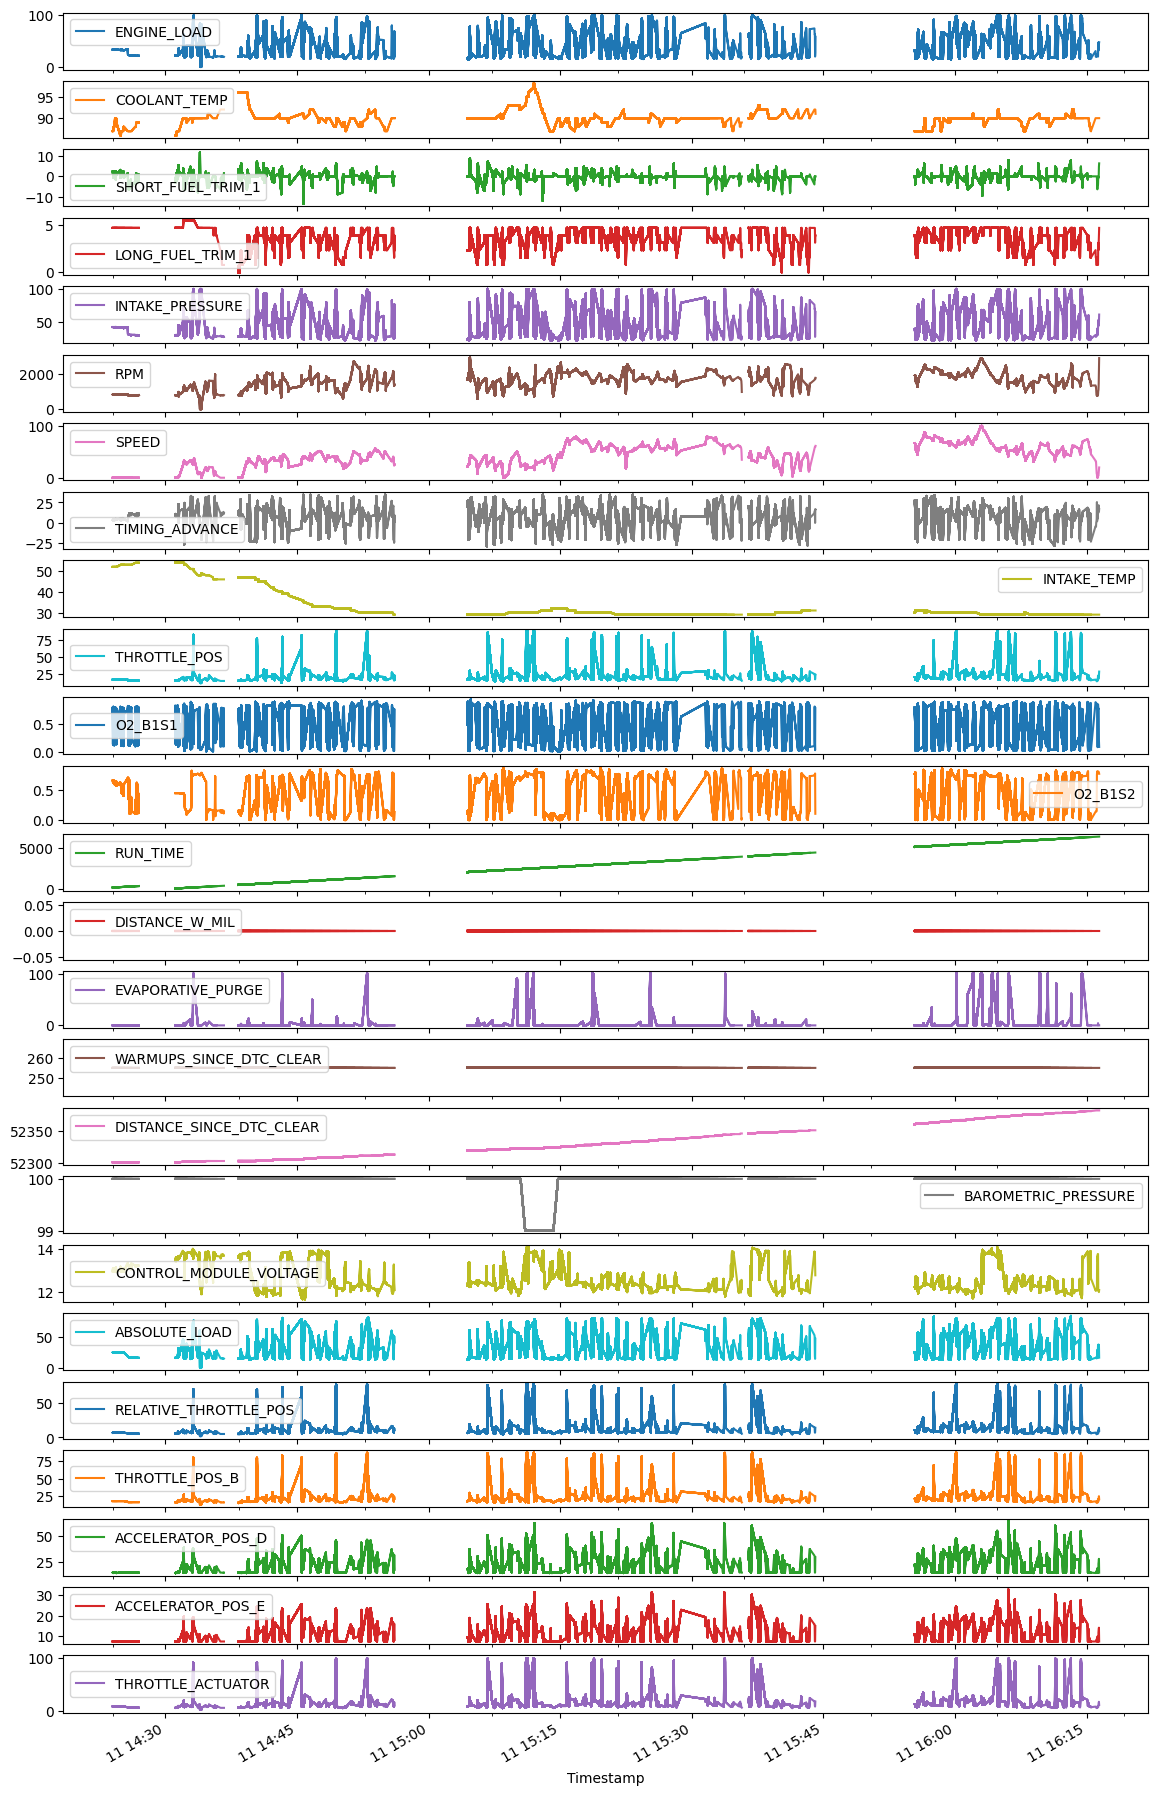

In [8]:
df.plot(subplots=True, figsize=(14,25))
plt.show()

In [9]:
df.describe()

,ENGINE_LOAD,COOLANT_TEMP,SHORT_FUEL_TRIM_1,LONG_FUEL_TRIM_1,INTAKE_PRESSURE,RPM,SPEED,TIMING_ADVANCE,INTAKE_TEMP,THROTTLE_POS,...,WARMUPS_SINCE_DTC_CLEAR,DISTANCE_SINCE_DTC_CLEAR,BAROMETRIC_PRESSURE,CONTROL_MODULE_VOLTAGE,ABSOLUTE_LOAD,RELATIVE_THROTTLE_POS,THROTTLE_POS_B,ACCELERATOR_POS_D,ACCELERATOR_POS_E,THROTTLE_ACTUATOR
count,18549.000000,18549.000000,18549.000000,18549.000000,18549.000000,18549.000000,18549.000000,18549.000000,18549.000000,18549.000000,...,18546.0,18543.000000,18543.000000,18543.000000,18543.000000,18543.000000,18543.000000,18543.000000,18543.000000,18543.000000
mean,41.371566,90.225295,-0.248539,3.487722,47.902097,1678.438164,44.876974,5.962801,32.365680,24.286284,...,255.0,52332.698539,99.913822,12.648557,33.609914,14.515726,24.490760,24.308946,12.250931,18.638818
std,26.176646,2.040979,2.378534,1.182728,25.082977,473.408214,22.048855,15.196481,6.119843,15.326807,...,0.0,23.618760,0.280634,0.651127,21.293440,15.321471,15.177541,10.307288,5.175170,19.580159
min,0.000000,86.000000,-13.281250,0.000000,21.000000,0.000000,0.000000,-28.500000,29.000000,11.764706,...,255.0,52301.000000,99.000000,11.661000,0.000000,1.960784,12.156863,14.509804,7.450980,2.745098
25%,19.215686,90.000000,-0.781250,2.343750,26.000000,1354.000000,29.000000,-3.000000,29.000000,16.862745,...,255.0,52319.000000,100.000000,12.156000,15.294118,7.450980,17.254902,14.901961,7.450980,9.411765
50%,30.588235,90.000000,0.000000,3.906250,37.000000,1687.000000,43.000000,8.000000,30.000000,19.215686,...,255.0,52324.000000,100.000000,12.392000,24.313725,9.803922,19.607843,21.960784,10.980392,12.549020
75%,61.176471,90.000000,0.000000,4.687500,67.000000,2037.500000,63.000000,17.000000,31.000000,24.705882,...,255.0,52361.000000,100.000000,13.075000,49.411765,14.901961,24.705882,30.588235,15.294118,18.823529
max,99.607843,98.000000,11.718750,5.468750,100.000000,2958.500000,101.000000,35.000000,54.000000,87.843137,...,255.0,52382.000000,100.000000,14.065000,85.098039,78.039216,87.450980,64.705882,32.549020,100.000000


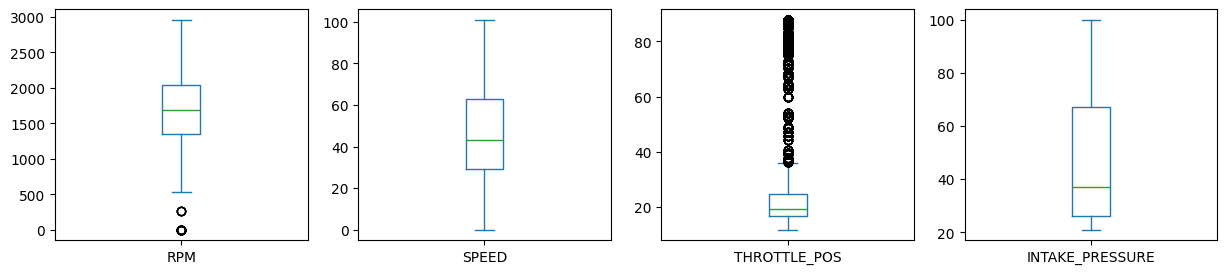

In [10]:
features = ['RPM', 'SPEED', 'THROTTLE_POS', 'INTAKE_PRESSURE']
df[features].plot(kind='box', subplots=True, figsize=(15,3))
plt.show()

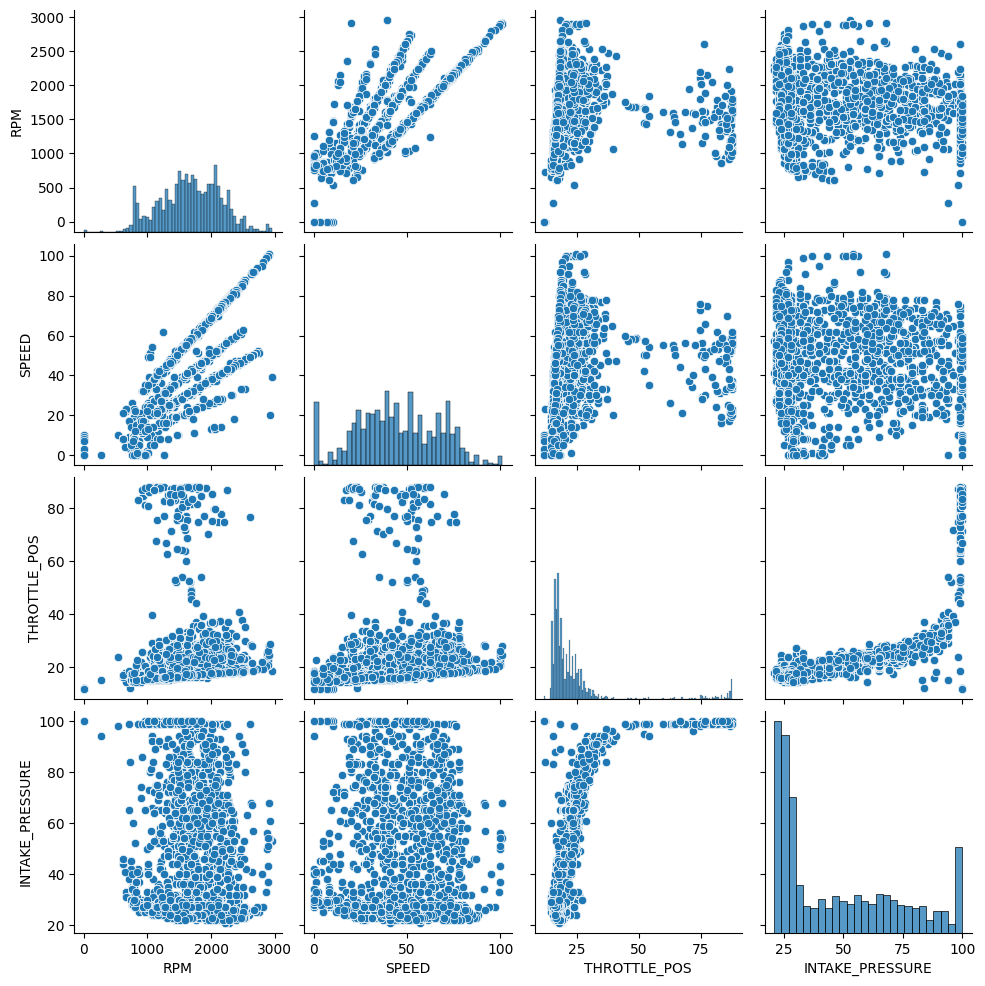

In [11]:
df = df.reset_index(drop=True)

try:
    sns.pairplot(df[features])
    plt.show()
except Exception as e:
    print(f"An error occurred: {str(e)}")

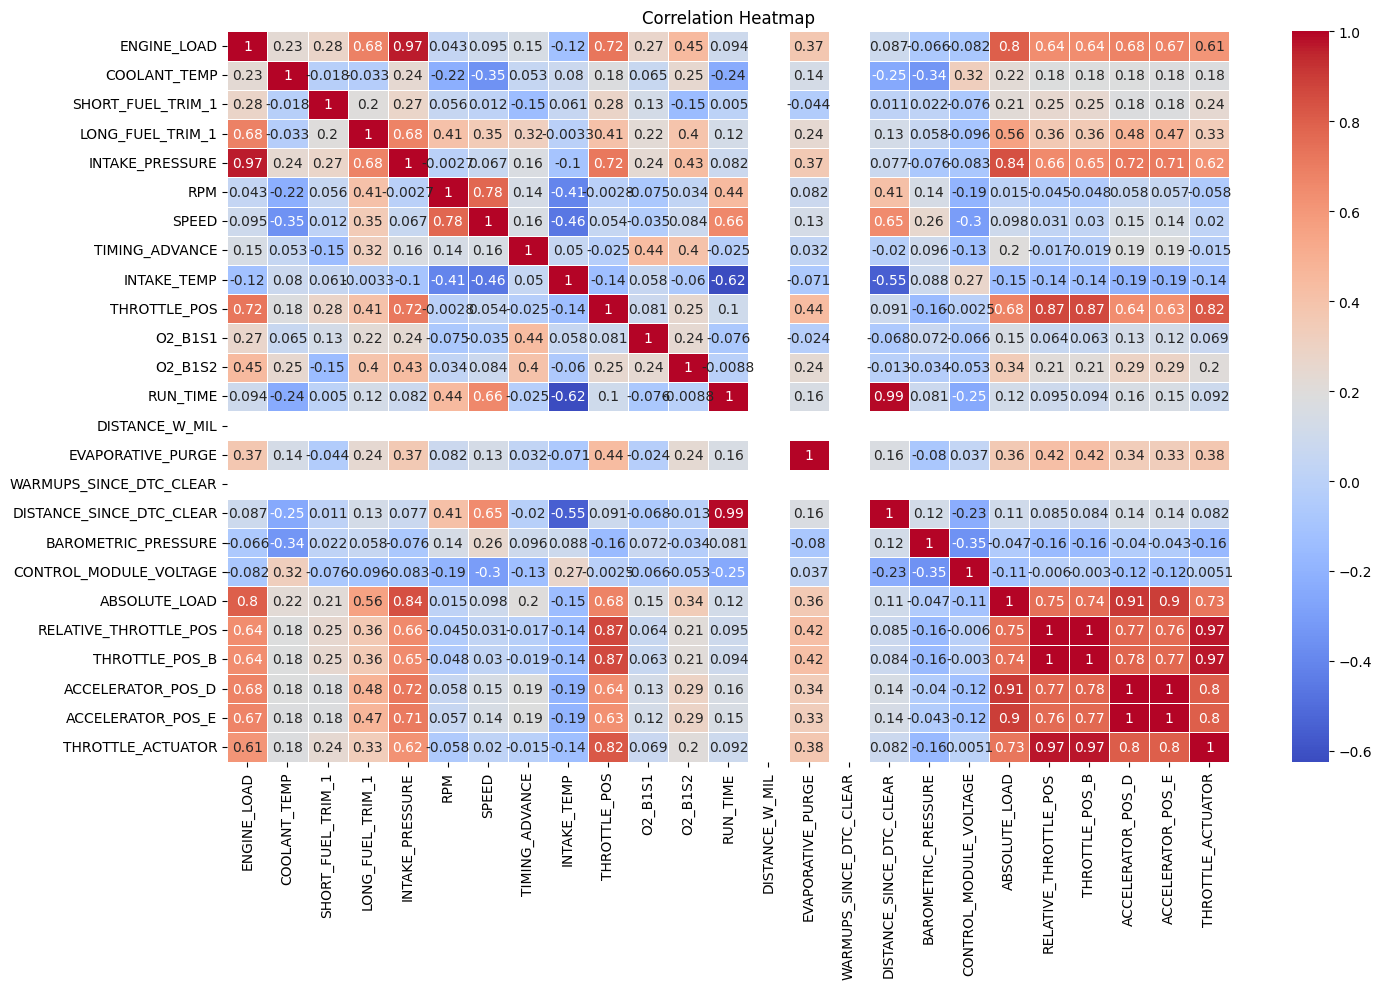

In [12]:
# plt.figure(figsize=(15,5))
# sns.heatmap(df.iloc[:,0:].corr(), annot=True)
# print(df[features].isna().sum())
# print(df[features].dtypes)
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Check if there are any numeric columns
if numeric_df.empty:
    print("Error: No numeric columns found in the DataFrame")
else:
    try:
        # Compute the correlation matrix
        corr_matrix = numeric_df.corr()

        # Create the plot
        plt.figure(figsize=(15, 10))  # Adjusted figure size for better visibility
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title('Correlation Heatmap')
        plt.tight_layout()  # Adjust the plot to ensure all elements are visible
        plt.show()
    except Exception as e:
        print(f"An error occurred: {str(e)}")

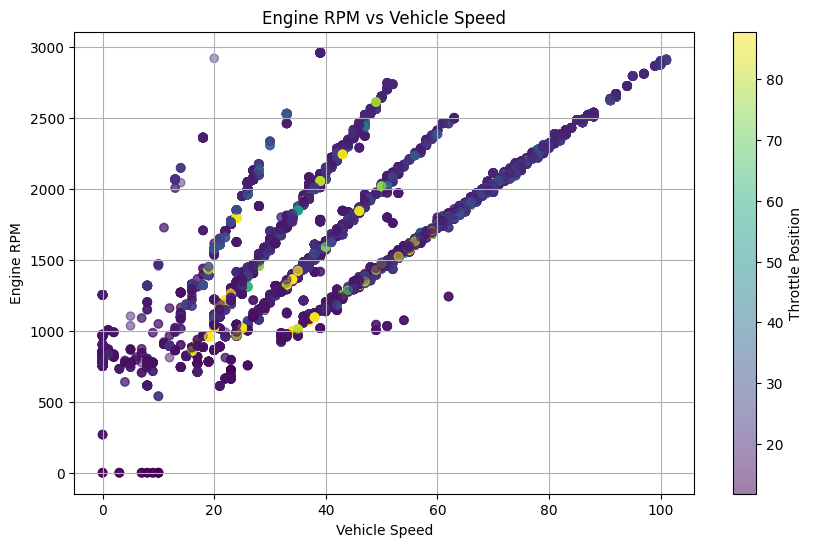

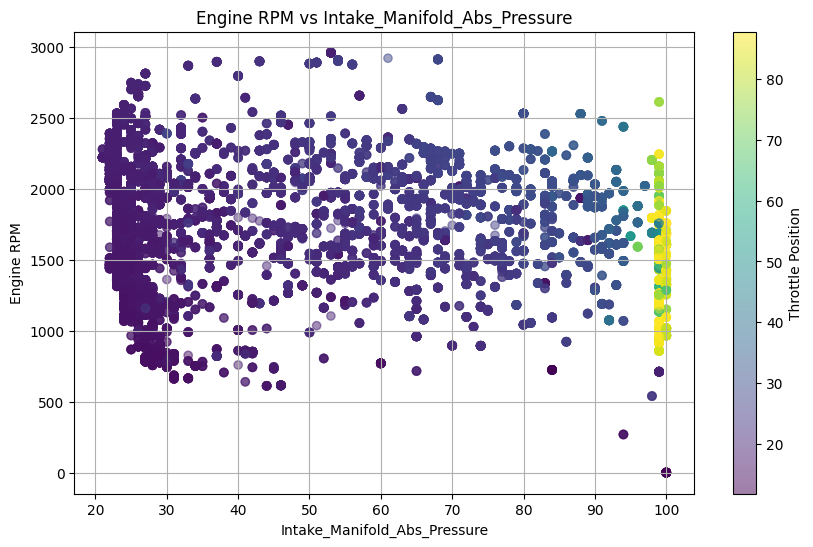

In [13]:
# select relevant columns for analysis (engine RPM, throttle position, airflow rate)
selected_columns = ['RPM', 'THROTTLE_POS', 'SPEED', 'INTAKE_PRESSURE']
engine_data = df[selected_columns]

# Plot engine RPM vs vehicle speed
plt.figure(figsize=(10, 6))
plt.scatter(engine_data['SPEED'], engine_data['RPM'], c=engine_data['THROTTLE_POS'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Throttle Position')
plt.xlabel('Vehicle Speed')
plt.ylabel('Engine RPM')
plt.title('Engine RPM vs Vehicle Speed')
plt.grid(True)
plt.show()


# Plot engine RPM vs vehicle speed
plt.figure(figsize=(10, 6))
plt.scatter(engine_data['INTAKE_PRESSURE'], engine_data['RPM'], c=engine_data['THROTTLE_POS'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Throttle Position')
plt.xlabel('Intake_Manifold_Abs_Pressure')
plt.ylabel('Engine RPM')
plt.title('Engine RPM vs Intake_Manifold_Abs_Pressure')
plt.grid(True)
plt.show()

# # Plot engine RPM vs throttle position
# plt.figure(figsize=(10, 6))
# plt.scatter(engine_data['THROTTLE_POS'], engine_data['RPM'], cmap='viridis', alpha=0.5)
# plt.colorbar(label='AirFlow Rate')
# plt.xlabel('Throttle Position')
# plt.ylabel('Engine RPM')
# plt.title('Engine RPM vs Throttle Position')
# plt.grid(True)
# plt.show()


# # Plot engine RPM vs airflow rate
# plt.figure(figsize=(10, 6))
# plt.scatter(engine_data['AirFlow_Rate'], engine_data['Engine_RPM'], c=engine_data['Throttle_Position'], cmap='viridis', alpha=0.5)
# plt.colorbar(label='Throttle Position')
# plt.xlabel('Airflow Rate')
# plt.ylabel('Engine RPM')
# plt.title('Engine RPM vs Airflow Rate')
# plt.grid(True)
# plt.show()


# **Driver Behaviour Analysis**
Sudden changes or erratic behaviour might indicate aggresive driving styles, which can increase wear and tear on the engine and other components

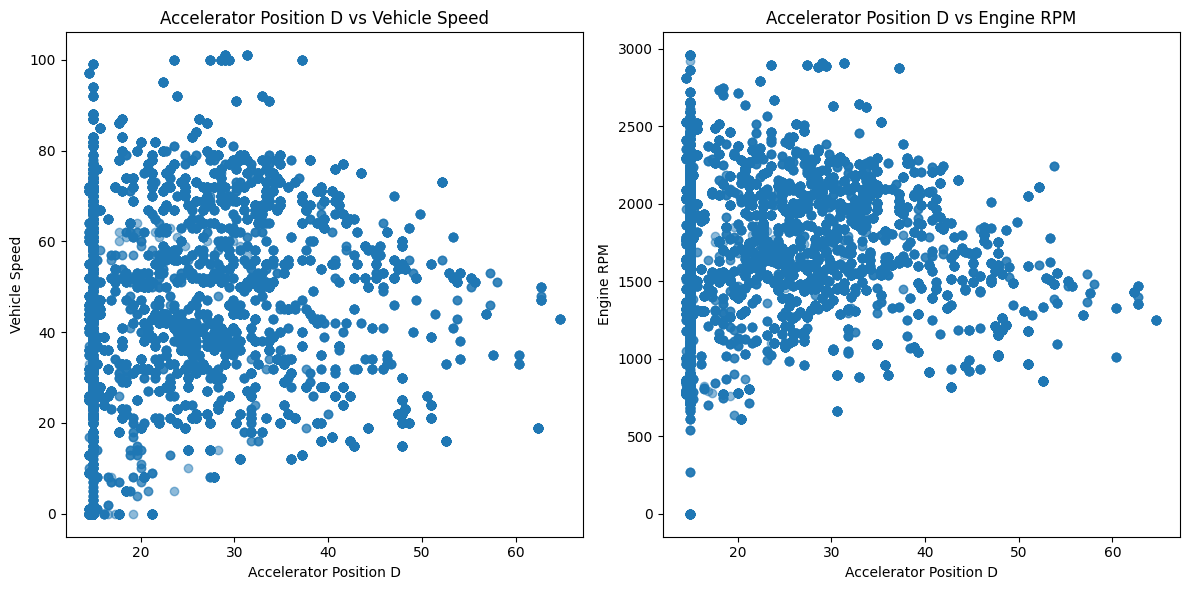

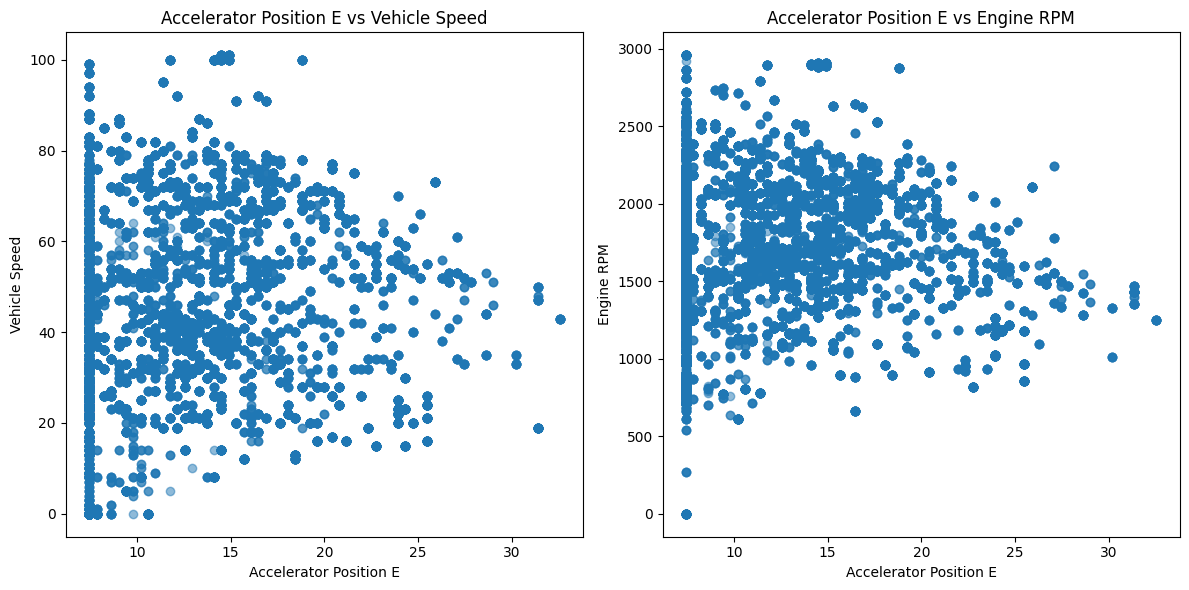

In [14]:
# Select relevant columns
relevant_cols = ['SPEED', 'RPM', 'ACCELERATOR_POS_D', 'ACCELERATOR_POS_E']
df = df[relevant_cols]

# Plotting accelerator pedal position D against vehicle speed and engine rpm
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(df['ACCELERATOR_POS_D'], df['SPEED'], alpha=0.5)
plt.title('Accelerator Position D vs Vehicle Speed')
plt.xlabel('Accelerator Position D')
plt.ylabel('Vehicle Speed')

plt.subplot(1, 2, 2)
plt.scatter(df['ACCELERATOR_POS_D'], df['RPM'], alpha=0.5)
plt.title('Accelerator Position D vs Engine RPM')
plt.xlabel('Accelerator Position D')
plt.ylabel('Engine RPM')

plt.tight_layout()
plt.show()

# Plotting accelerator pedal position E against vehicle speed and engine rpm
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(df['ACCELERATOR_POS_E'], df['SPEED'], alpha=0.5)
plt.title('Accelerator Position E vs Vehicle Speed')
plt.xlabel('Accelerator Position E')
plt.ylabel('Vehicle Speed')

plt.subplot(1, 2, 2)
plt.scatter(df['ACCELERATOR_POS_E'], df['RPM'], alpha=0.5)
plt.title('Accelerator Position E vs Engine RPM')
plt.xlabel('Accelerator Position E')
plt.ylabel('Engine RPM')


plt.tight_layout()
plt.show()

Text(0, 0.5, 'Engine RPM')

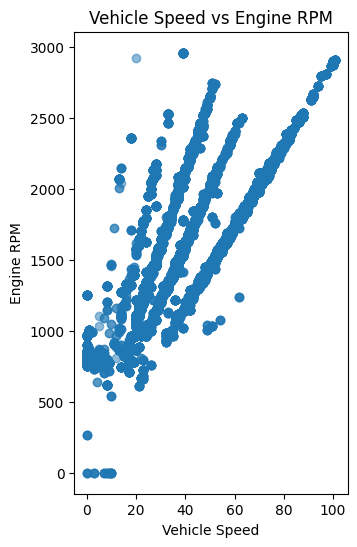

In [15]:
# Plotting vehicle speed against RPM
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.scatter(df['SPEED'], df['RPM'], alpha=0.5)
plt.title('Vehicle Speed vs Engine RPM')
plt.xlabel('Vehicle Speed')
plt.ylabel('Engine RPM')

# **Investigating high speed braking**

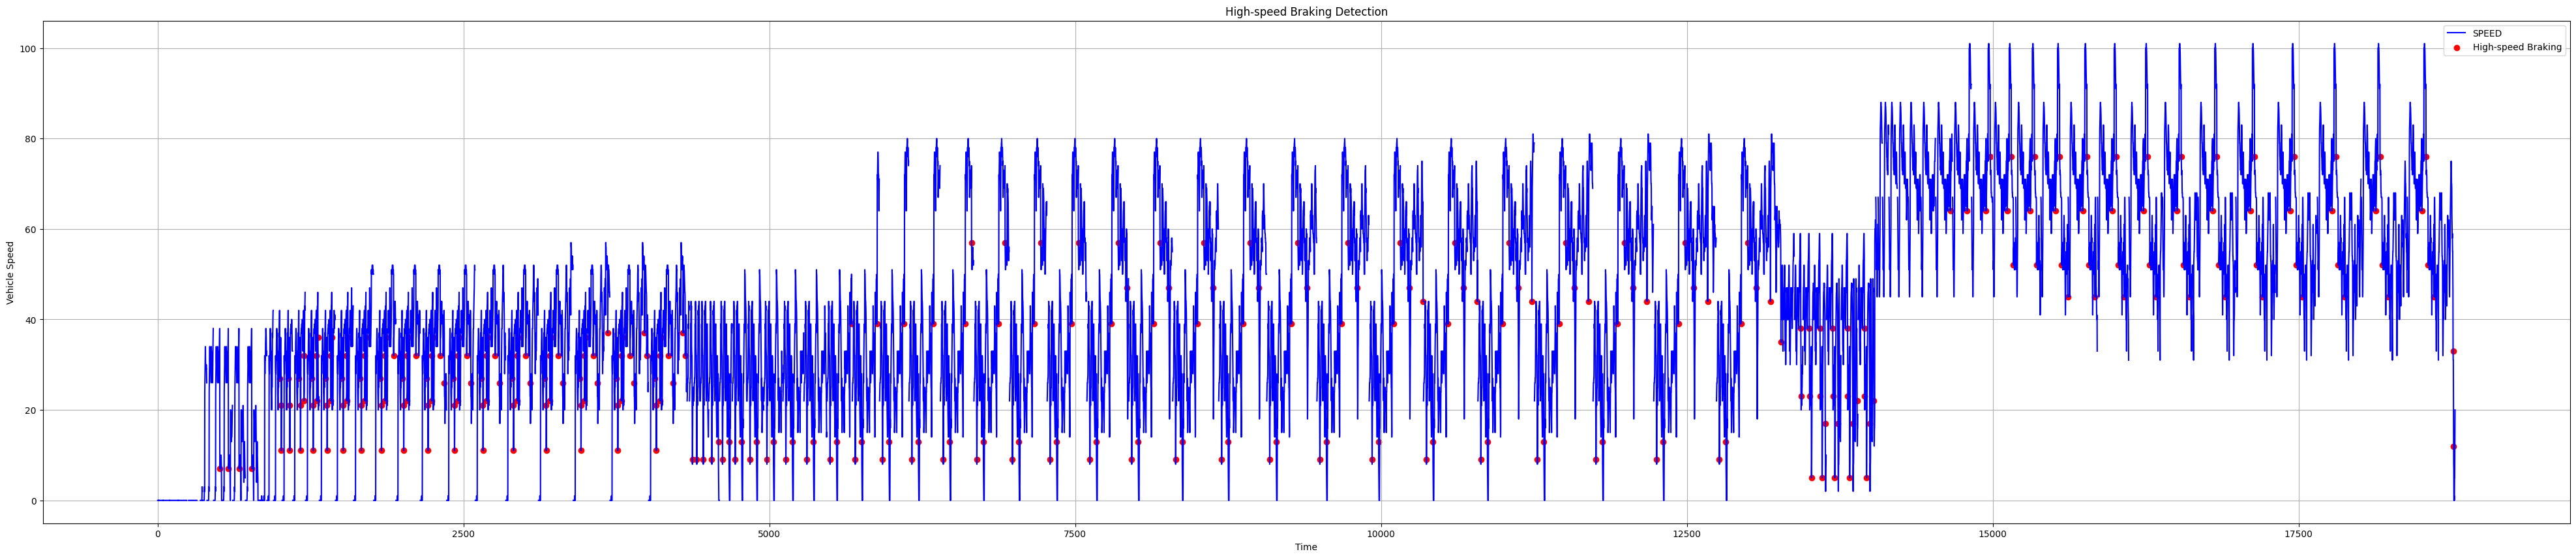

In [16]:
vehicle_speed = df["SPEED"]
time_interval = 1
speed_change = vehicle_speed.diff() / time_interval
braking_threshold = -10 # This is an assumption
# Detect high-speed braking events
high_speed_braking_indices = speed_change[speed_change <= braking_threshold].index

# Plot vehicle speed
plt.figure(figsize=(50,10))
plt.plot(df.index, vehicle_speed, label="SPEED", color="blue")
plt.scatter(high_speed_braking_indices, vehicle_speed.loc[high_speed_braking_indices], color="red", label="High-speed Braking")
plt.xlabel("Time")
plt.ylabel("Vehicle Speed")
plt.title("High-speed Braking Detection")
plt.legend()
plt.grid(True)
plt.show()

# **Fault detection**

In [17]:
# Define thresholds or ranges for each feature to detect anomalies
thresholds = {
    'COOLANT_TEMP': (80, 100),  # Example: normal range is 80-100°C
    'INTAKE_PRESSURE': (80, 120),  # Example: normal range is 80-120 kPa
    'RPM': (1000, 6000),  # Example: normal range is 1000-6000 RPM
    'INTAKE_TEMP': (20, 40),  # Example: normal range is 20-40°C
    'THROTTLE_POS': (0, 100),  # Example: normal range is 0-100%
    'Air_Temperature': (-10, 40),  # Example: normal range is -10-40°C
    'ACCELERATOR_POS_D': (0, 100),  # Example: normal range is 0-100%
    'ACCELERATOR_POS_E': (0, 100)  # Example: normal range is 0-100%
}

def perform_diagnosis(df, thresholds):
    diagnosis_results = {}

    for feature, (min_val, max_val) in thresholds.items():
        if feature not in df.columns:
            print(f"Warning: {feature} not found in the DataFrame")
            continue

        try:
            # Convert column to numeric, coercing errors to NaN
            df[feature] = pd.to_numeric(df[feature], errors='coerce')

            # Check for values outside the normal range
            anomalies = df[(df[feature] < min_val) | (df[feature] > max_val)]

            if not anomalies.empty:
                diagnosis_results[feature] = anomalies
        except Exception as e:
            print(f"Error processing {feature}: {str(e)}")

    return diagnosis_results

# Perform diagnosis
diagnosis_results = perform_diagnosis(df, thresholds)

# Print diagnosis results
for feature, anomalies in diagnosis_results.items():
    print(f"Anomalies detected for {feature}:")
    print(anomalies)
    print()

Anomalies detected for RPM:
       SPEED    RPM  ACCELERATOR_POS_D  ACCELERATOR_POS_E
0        0.0  851.5          14.901961           7.450980
1        0.0  850.5          14.901961           7.450980
2        0.0  851.0          14.901961           7.450980
3        0.0  851.0          14.901961           7.450980
4        0.0  849.0          14.901961           7.450980
...      ...    ...                ...                ...
18770    0.0  821.5          16.470588           8.627451
18771    0.0  758.0          19.215686           9.803922
18772    1.0  826.0          14.901961           7.450980
18773    0.0  781.0          17.254902           8.627451
18774    1.0  834.0          14.901961           7.450980

[1845 rows x 4 columns]



Anomalies detected for RPM:
       SPEED    RPM  ACCELERATOR_POS_D  ACCELERATOR_POS_E
0        0.0  851.5          14.901961           7.450980
1        0.0  850.5          14.901961           7.450980
2        0.0  851.0          14.901961           7.450980
3        0.0  851.0          14.901961           7.450980
4        0.0  849.0          14.901961           7.450980
...      ...    ...                ...                ...
18770    0.0  821.5          16.470588           8.627451
18771    0.0  758.0          19.215686           9.803922
18772    1.0  826.0          14.901961           7.450980
18773    0.0  781.0          17.254902           8.627451
18774    1.0  834.0          14.901961           7.450980

[1845 rows x 4 columns]



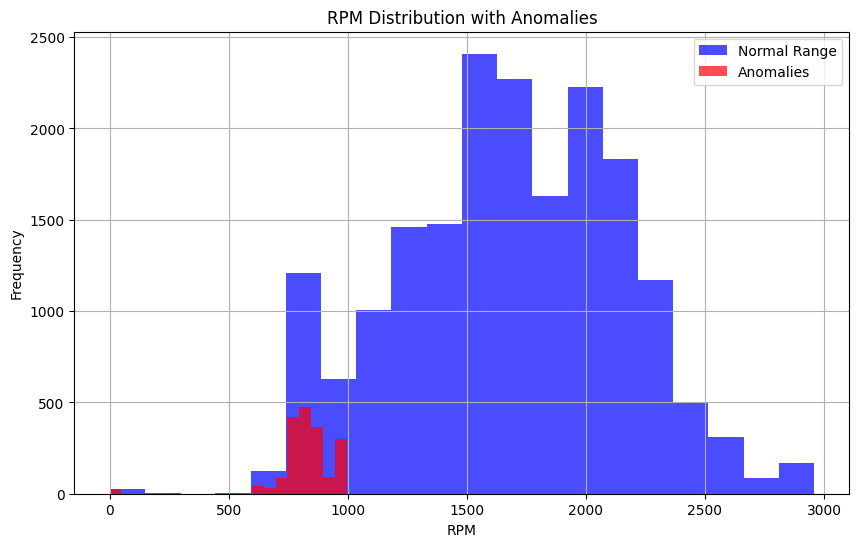

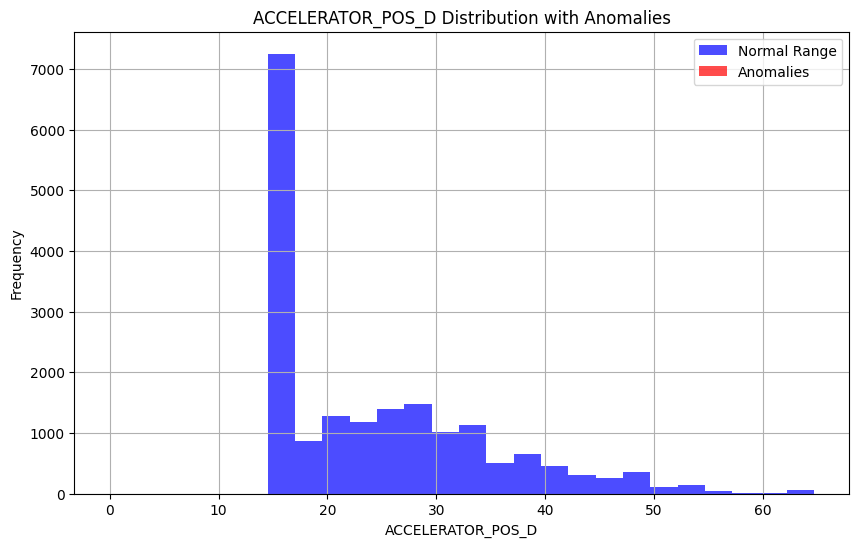

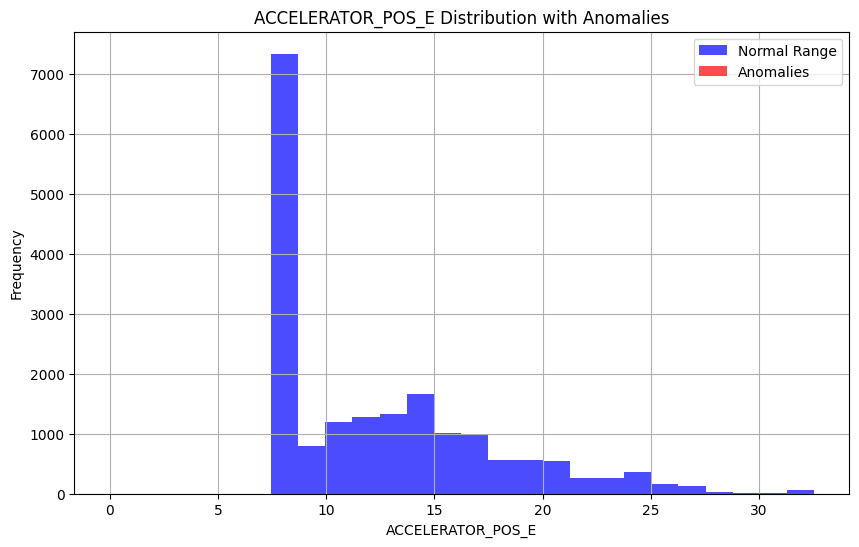

In [18]:
# Define thresholds or ranges for each feature to detect anomalies
thresholds = {
    'COOLANT_TEMP': (80, 100),  # Example: normal range is 80-100°C
    'INTAKE_PRESSURE': (80, 120),  # Example: normal range is 80-120 kPa
    'RPM': (1000, 6000),  # Example: normal range is 1000-6000 RPM
    'INTAKE_TEMP': (20, 40),  # Example: normal range is 20-40°C
    'THROTTLE_POS': (0, 100),  # Example: normal range is 0-100%
    'ACCELERATOR_POS_D': (0, 100),  # Example: normal range is 0-100%
    'ACCELERATOR_POS_E': (0, 100)  # Example: normal range is 0-100%
}

def perform_diagnosis(df, thresholds):
    diagnosis_results = {}

    for feature, (min_val, max_val) in thresholds.items():
        if feature not in df.columns:
            print(f"Warning: {feature} not found in the DataFrame")
            continue

        try:
            # Convert column to numeric, coercing errors to NaN
            df[feature] = pd.to_numeric(df[feature], errors='coerce')

            # Check for values outside the normal range
            anomalies = df[(df[feature] < min_val) | (df[feature] > max_val)]

            if not anomalies.empty:
                diagnosis_results[feature] = anomalies
        except Exception as e:
            print(f"Error processing {feature}: {str(e)}")

    return diagnosis_results

def visualize_anomalies(df, thresholds):
    for feature, (min_val, max_val) in thresholds.items():
        if feature not in df.columns:
            print(f"Warning: {feature} not found in the DataFrame")
            continue

        try:
            # Convert column to numeric, coercing errors to NaN
            df[feature] = pd.to_numeric(df[feature], errors='coerce')

            # Check for values outside the normal range
            anomalies = df[(df[feature] < min_val) | (df[feature] > max_val)]

            # Plot feature distribution with anomalies highlighted
            plt.figure(figsize=(10, 6))
            plt.hist(df[feature].dropna(), bins=20, color='blue', alpha=0.7, label='Normal Range')
            plt.hist(anomalies[feature].dropna(), bins=20, color='red', alpha=0.7, label='Anomalies')
            plt.xlabel(feature)
            plt.ylabel('Frequency')
            plt.title(f'{feature} Distribution with Anomalies')
            plt.legend()
            plt.grid(True)
            plt.show()
        except Exception as e:
            print(f"Error visualizing {feature}: {str(e)}")

# Perform diagnosis
diagnosis_results = perform_diagnosis(df, thresholds)

# Print diagnosis results
for feature, anomalies in diagnosis_results.items():
    print(f"Anomalies detected for {feature}:")
    print(anomalies)
    print()

# Visualize anomalies
visualize_anomalies(df, thresholds)